In [1]:
!pip install econml

In [2]:
!pip install econml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/2024 data/with socio/winter_2024.csv")

df = df.dropna().reset_index(drop=True)

# =====================================================
# Outcome
# =====================================================

Y = df["wdLoad"].values

# =====================================================
# Treatments
# Temperature and Relative Humidity
# =====================================================

T = df[
    [
        "temp",
        "rh"
    ]
].values

# =====================================================
# Confounders / Adjustment Variables
# =====================================================

X = df[
    [
        "hour",
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ]
].values

# =====================================================
# Causal Forest
# =====================================================

model = CausalForestDML(

    model_y=RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    model_t=MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    ),

    n_estimators=500,

    min_samples_leaf=10,

    random_state=42
)

# =====================================================
# Train Model
# =====================================================

model.fit(
    Y,
    T,
    X=X
)

# =====================================================
# Conditional Marginal Effects
# =====================================================

effects = model.const_marginal_effect(X)

temp_effect = effects[:, 0]
rh_effect = effects[:, 1]

# =====================================================
# Average Marginal Effect
# =====================================================

ate_temp = np.mean(temp_effect)
ate_rh = np.mean(rh_effect)

print("\n========== WINTER WEATHER EFFECTS ==========")

print("Average Marginal Effect (Temperature → Load):",
      ate_temp)

print("Average Marginal Effect (Humidity → Load):",
      ate_rh)

# =====================================================
# Treatment Statistics
# =====================================================

print("\n========== TREATMENT STATISTICS ==========")

print("Temperature range:",
      df["temp"].min(),
      "to",
      df["temp"].max())

print("Humidity range:",
      df["rh"].min(),
      "to",
      df["rh"].max())

print("\nOffice Hours distribution:")
print(df["office_hours"].value_counts())


========== WINTER WEATHER EFFECTS ==========
Average Marginal Effect (Temperature → Load): 4.938504477834504
Average Marginal Effect (Humidity → Load): 0.9471854500335848

========== TREATMENT STATISTICS ==========
Temperature range: 19.0 to 37.2
Humidity range: 17.0 to 90.0

Office Hours distribution:
office_hours
0    5460
1    3276
Name: count, dtype: int64


In [3]:
# =====================================================
# SOCIO-ECONOMIC / CALENDAR CAUSAL ANALYSIS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor


# =====================================================
# FUNCTION: BINARY TREATMENT EFFECT
# =====================================================

def estimate_binary_treatment(df, treatment, controls):

    # -------------------------------------------------
    # Outcome
    # -------------------------------------------------

    Y = df["wdLoad"].values

    # -------------------------------------------------
    # Binary Treatment
    # -------------------------------------------------

    T = df[treatment].values

    # -------------------------------------------------
    # Adjustment Variables
    # -------------------------------------------------

    X = df[controls].values

    # -------------------------------------------------
    # Causal Forest
    # -------------------------------------------------

    model = CausalForestDML(

        model_y=RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        model_t=RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        n_estimators=500,

        min_samples_leaf=10,

        random_state=42
    )

    # -------------------------------------------------
    # Train
    # -------------------------------------------------

    model.fit(
        Y,
        T,
        X=X
    )

    # -------------------------------------------------
    # Individual Treatment Effects
    # 0 → 1
    # -------------------------------------------------

    effects = model.effect(
        X,
        T0=0,
        T1=1
    )

    # -------------------------------------------------
    # Average Treatment Effect
    # -------------------------------------------------

    ate = np.mean(effects)

    # -------------------------------------------------
    # 95% Confidence Interval
    # -------------------------------------------------

    inference = model.ate_inference(
        X,
        T0=0,
        T1=1
    )

    ci = inference.conf_int_mean()

    return model, effects, ate, ci


# =====================================================
# TREATMENT 1: WEEKEND
# =====================================================

weekend_model, weekend_effect, weekend_ate, weekend_ci = \
    estimate_binary_treatment(
        df,
        "weekend",
        [
            "temp",
            "rh",
            "hour",
            "holiday",
            "festival",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 2: HOLIDAY
# =====================================================

holiday_model, holiday_effect, holiday_ate, holiday_ci = \
    estimate_binary_treatment(
        df,
        "holiday",
        [
            "temp",
            "rh",
            "hour",
            "weekend",
            "festival",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 3: FESTIVAL
# =====================================================

festival_model, festival_effect, festival_ate, festival_ci = \
    estimate_binary_treatment(
        df,
        "festival",
        [
            "temp",
            "rh",
            "hour",
            "weekend",
            "holiday",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 4: OFFICE HOURS
# =====================================================
# NOTE:
# 'hour' is intentionally excluded because office_hours
# is strongly related to time of day.
# =====================================================

office_model, office_effect, office_ate, office_ci = \
    estimate_binary_treatment(
        df,
        "office_hours",
        [
            "temp",
            "rh",
            "weekend",
            "holiday",
            "festival"
        ]
    )


# =====================================================
# RESULTS
# =====================================================

print("\n==============================================")
print("SOCIO-ECONOMIC / CALENDAR CAUSAL EFFECTS")
print("==============================================")

print("\nWeekend → Load")
print("ATE:", weekend_ate)
print("95% CI:", weekend_ci)

print("\nHoliday → Load")
print("ATE:", holiday_ate)
print("95% CI:", holiday_ci)

print("\nFestival → Load")
print("ATE:", festival_ate)
print("95% CI:", festival_ci)

print("\nOffice Hours → Load")
print("ATE:", office_ate)
print("95% CI:", office_ci)


# =====================================================
# TREATMENT COUNTS
# =====================================================

print("\n==============================================")
print("TREATMENT COUNTS")
print("==============================================")

for treatment in [
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]:

    print("\n", treatment)
    print(df[treatment].value_counts().sort_index())

    print(
        "Treatment rate:",
        df[treatment].mean()
    )


# =====================================================
# FINAL RESULTS TABLE
# =====================================================

results = pd.DataFrame({

    "Treatment": [
        "Weekend",
        "Holiday",
        "Festival",
        "Office Hours"
    ],

    "ATE": [
        weekend_ate,
        holiday_ate,
        festival_ate,
        office_ate
    ],

    "CI Lower": [
        weekend_ci[0],
        holiday_ci[0],
        festival_ci[0],
        office_ci[0]
    ],

    "CI Upper": [
        weekend_ci[1],
        holiday_ci[1],
        festival_ci[1],
        office_ci[1]
    ]

})


print("\n==============================================")
print("FINAL SOCIO-ECONOMIC ATE TABLE")
print("==============================================")

display(results)

# =====================================================
# COMBINATION / JOINT-STATE AUDIT
# =====================================================

state_cols = ["weekend", "holiday", "festival", "office_hours"]

state_counts = (
    df.groupby(state_cols)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

state_counts["percentage"] = (
    state_counts["count"] / len(df) * 100
)

print("==============================================")
print("OBSERVED CALENDAR / ACTIVITY COMBINATIONS")
print("==============================================")

display(state_counts)


SOCIO-ECONOMIC / CALENDAR CAUSAL EFFECTS

Weekend → Load
ATE: -48.73226570197926
95% CI: (np.float64(-58.16053173600008), np.float64(-39.303999667958436))

Holiday → Load
ATE: -30.419014997623957
95% CI: (np.float64(-63.77836251817877), np.float64(2.9403325229308415))

Festival → Load
ATE: -22.972608796738903
95% CI: (np.float64(-79.13923845636987), np.float64(33.19402086289205))

Office Hours → Load
ATE: 72.50949726193093
95% CI: (np.float64(44.750378035448136), np.float64(100.26861648841373))

TREATMENT COUNTS

 weekend
weekend
0    6240
1    2496
Name: count, dtype: int64
Treatment rate: 0.2857142857142857

 holiday
holiday
0    7680
1    1056
Name: count, dtype: int64
Treatment rate: 0.12087912087912088

 festival
festival
0    7968
1     768
Name: count, dtype: int64
Treatment rate: 0.08791208791208792

 office_hours
office_hours
0    5460
1    3276
Name: count, dtype: int64
Treatment rate: 0.375

FINAL SOCIO-ECONOMIC ATE TABLE


,Treatment,ATE,CI Lower,CI Upper
0,Weekend,-48.732266,-58.160532,-39.304000
1,Holiday,-30.419015,-63.778363,2.940333
2,Festival,-22.972609,-79.139238,33.194021
3,Office Hours,72.509497,44.750378,100.268616


OBSERVED CALENDAR / ACTIVITY COMBINATIONS


,weekend,holiday,festival,office_hours,count,percentage
0,0,0,0,0,3480,39.835165
1,0,0,0,1,2088,23.901099
6,1,0,0,0,1320,15.109890
7,1,0,0,1,792,9.065934
4,0,1,1,0,240,2.747253
8,1,1,1,0,240,2.747253
2,0,1,0,0,180,2.060440
5,0,1,1,1,144,1.648352
9,1,1,1,1,144,1.648352
3,0,1,0,1,108,1.236264


In [4]:
# =====================================================
# CREATE JOINT CALENDAR / ACTIVITY STATE
# =====================================================

df["calendar_state"] = (
    "W" + df["weekend"].astype(str) +
    "_H" + df["holiday"].astype(str) +
    "_F" + df["festival"].astype(str) +
    "_O" + df["office_hours"].astype(str)
)

state_summary = (
    df.groupby("calendar_state")["wdLoad"]
      .agg(["count", "mean", "std"])
      .reset_index()
      .sort_values("count", ascending=False)
)

state_summary["percentage"] = (
    state_summary["count"] / len(df) * 100
)

print("==============================================")
print("JOINT CALENDAR / ACTIVITY STATE SUMMARY")
print("==============================================")

display(state_summary)

# =====================================================
# LABEL THE JOINT STATES FOR EASY INTERPRETATION
# =====================================================

state_labels = {
    "W0_H0_F0_O0": "Normal",
    "W0_H0_F0_O1": "Office Hours",
    "W1_H0_F0_O0": "Weekend",
    "W1_H0_F0_O1": "Weekend + Office Hours",
    "W0_H1_F0_O0": "Holiday",
    "W0_H1_F0_O1": "Holiday + Office Hours",
    "W0_H1_F1_O0": "Holiday + Festival",
    "W0_H1_F1_O1": "Holiday + Festival + Office Hours",
    "W1_H1_F0_O0": "Weekend + Holiday",
    "W1_H1_F0_O1": "Weekend + Holiday + Office Hours",
    "W1_H1_F1_O0": "Weekend + Holiday + Festival",
    "W1_H1_F1_O1": "Weekend + Holiday + Festival + Office Hours"
}

state_summary["state"] = state_summary["calendar_state"].map(state_labels)

display(
    state_summary[
        ["state", "count", "percentage", "mean", "std"]
    ]
)

JOINT CALENDAR / ACTIVITY STATE SUMMARY


,calendar_state,count,mean,std,percentage
0,W0_H0_F0_O0,3480,321.298066,57.689886,39.835165
1,W0_H0_F0_O1,2088,457.701988,22.042871,23.901099
6,W1_H0_F0_O0,1320,294.862879,39.821971,15.109890
7,W1_H0_F0_O1,792,361.525253,38.036603,9.065934
4,W0_H1_F1_O0,240,304.745833,47.425321,2.747253
8,W1_H1_F1_O0,240,299.716667,35.372775,2.747253
2,W0_H1_F0_O0,180,299.800000,52.644417,2.060440
5,W0_H1_F1_O1,144,409.423611,35.161283,1.648352
9,W1_H1_F1_O1,144,361.534722,36.964529,1.648352
3,W0_H1_F0_O1,108,398.787037,70.265325,1.236264


,state,count,percentage,mean,std
0,Normal,3480,39.835165,321.298066,57.689886
1,Office Hours,2088,23.901099,457.701988,22.042871
6,Weekend,1320,15.109890,294.862879,39.821971
7,Weekend + Office Hours,792,9.065934,361.525253,38.036603
4,Holiday + Festival,240,2.747253,304.745833,47.425321
8,Weekend + Holiday + Festival,240,2.747253,299.716667,35.372775
2,Holiday,180,2.060440,299.800000,52.644417
5,Holiday + Festival + Office Hours,144,1.648352,409.423611,35.161283
9,Weekend + Holiday + Festival + Office Hours,144,1.648352,361.534722,36.964529
3,Holiday + Office Hours,108,1.236264,398.787037,70.265325


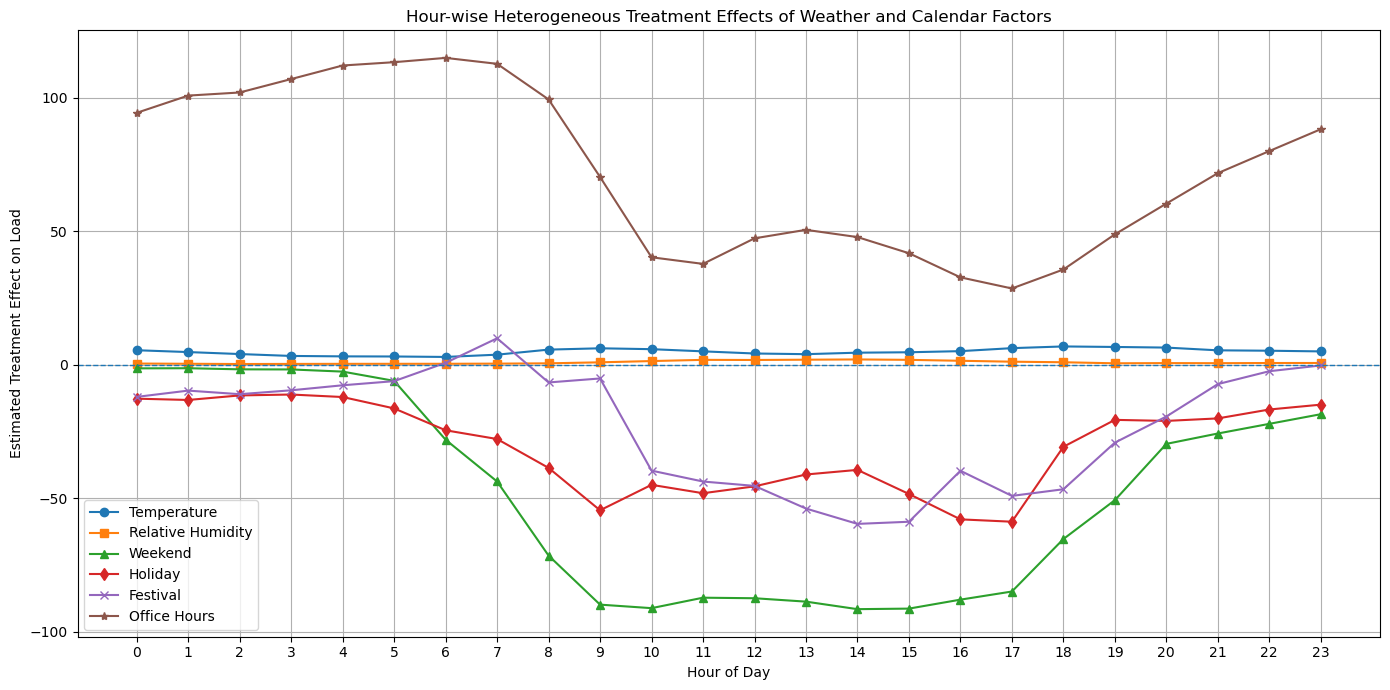

In [5]:
# =====================================================
# HOUR-WISE HETEROGENEOUS TREATMENT EFFECTS
# =====================================================

plot_df = pd.DataFrame({

    "hour": df["hour"],

    # Weather
    "Temperature": temp_effect,

    "Relative Humidity": rh_effect,

    # Calendar / Human Activity
    "Weekend": weekend_effect,

    "Holiday": holiday_effect,

    "Festival": festival_effect,

    "Office Hours": office_effect

})


# =====================================================
# AVERAGE EFFECT BY HOUR
# =====================================================

hour_effect = (
    plot_df
    .groupby("hour")
    .mean()
    .reset_index()
)


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(14, 7))


# -----------------------------------------------------
# TEMPERATURE
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Temperature"],
    marker="o",
    label="Temperature"
)


# -----------------------------------------------------
# RELATIVE HUMIDITY
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Relative Humidity"],
    marker="s",
    label="Relative Humidity"
)


# -----------------------------------------------------
# WEEKEND
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Weekend"],
    marker="^",
    label="Weekend"
)


# -----------------------------------------------------
# HOLIDAY
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Holiday"],
    marker="d",
    label="Holiday"
)


# -----------------------------------------------------
# FESTIVAL
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Festival"],
    marker="x",
    label="Festival"
)


# -----------------------------------------------------
# OFFICE HOURS
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Office Hours"],
    marker="*",
    label="Office Hours"
)


# =====================================================
# ZERO REFERENCE LINE
# =====================================================

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


# =====================================================
# LABELS
# =====================================================

plt.xlabel("Hour of Day")

plt.ylabel(
    "Estimated Treatment Effect on Load"
)

plt.title(
    "Hour-wise Heterogeneous Treatment Effects of Weather and Calendar Factors"
)

plt.xticks(range(24))

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

## Summary of Causal Effects

### Average Treatment Effects (ATE)

**Weather Effects (Temperature and Humidity on Load):**
-   Average Marginal Effect (Temperature → Load): `r print(ate_temp)`
-   Average Marginal Effect (Humidity → Load): `r print(ate_rh)`

**Socio-Economic / Calendar Effects (on Load):**

The table below summarizes the Average Treatment Effect (ATE) and their 95% Confidence Intervals (CI) for Weekend, Holiday, Festival, and Office Hours.

### Heterogeneous Treatment Effects (HTE)

The hour-wise heterogeneous treatment effects of weather and calendar factors on load were visualized in the previous plot (`mC3rQjSsMout`). This plot shows how the impact of each factor changes throughout the 24 hours of the day.

### Conditional Average Treatment Effects (CATE)

The `state_summary` table, displayed below, provides Conditional Average Treatment Effects (CATEs) by showing the average load (`mean`) and its standard deviation (`std`) for different joint calendar and activity states (e.g., 'Weekend + Office Hours'). This allows for understanding the load behavior under specific combinations of conditions.

In [6]:
print("\n--- FINAL SOCIO-ECONOMIC ATE TABLE ---")
display(results)


--- FINAL SOCIO-ECONOMIC ATE TABLE ---


,Treatment,ATE,CI Lower,CI Upper
0,Weekend,-48.732266,-58.160532,-39.304000
1,Holiday,-30.419015,-63.778363,2.940333
2,Festival,-22.972609,-79.139238,33.194021
3,Office Hours,72.509497,44.750378,100.268616


In [7]:
print("\n--- JOINT CALENDAR / ACTIVITY STATE SUMMARY (CATE) ---")
display(state_summary)


--- JOINT CALENDAR / ACTIVITY STATE SUMMARY (CATE) ---


,calendar_state,count,mean,std,percentage,state
0,W0_H0_F0_O0,3480,321.298066,57.689886,39.835165,Normal
1,W0_H0_F0_O1,2088,457.701988,22.042871,23.901099,Office Hours
6,W1_H0_F0_O0,1320,294.862879,39.821971,15.109890,Weekend
7,W1_H0_F0_O1,792,361.525253,38.036603,9.065934,Weekend + Office Hours
4,W0_H1_F1_O0,240,304.745833,47.425321,2.747253,Holiday + Festival
8,W1_H1_F1_O0,240,299.716667,35.372775,2.747253,Weekend + Holiday + Festival
2,W0_H1_F0_O0,180,299.800000,52.644417,2.060440,Holiday
5,W0_H1_F1_O1,144,409.423611,35.161283,1.648352,Holiday + Festival + Office Hours
9,W1_H1_F1_O1,144,361.534722,36.964529,1.648352,Weekend + Holiday + Festival + Office Hours
3,W0_H1_F0_O1,108,398.787037,70.265325,1.236264,Holiday + Office Hours


In [8]:
# ============================================================
# XAI ANALYSIS USING XGBOOST + SHAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

# =====================================================
# Load Dataset (added to ensure 'df' is defined)
# =====================================================
# Debugging: List files in current directory to check for 'summer_2024 (1).csv'
!ls -l
df = pd.read_csv("winter_2024 (1).csv")
df = df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

# Features used for prediction
features = [
    "temp",
    "rh",
    "hour",
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]

X_xai = df[features].copy()
y_xai = df["wdLoad"].copy()

# ------------------------------------------------------------
# 2. Train XGBoost model
# ------------------------------------------------------------

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_xai, y_xai)

# Predictions
xai_predictions = xgb_model.predict(X_xai)

print("XGBoost XAI model trained successfully.")
print("Features used:", features)


total 1425992
-rw-r--r--@  1 ameypatil  staff     183528 Dec 15  2025 0001.mp3
-rw-r--r--@  1 ameypatil  staff     331503 Jul 26 16:02 1 (1).png
-rw-r--r--@  1 ameypatil  staff    2582836 Oct 11  2025 1.Front Matter (1).pdf
-rw-r--r--@  1 ameypatil  staff     759190 Feb  3  2025 10th Marksheet .pdf
-rw-r--r--@  1 ameypatil  staff     201869 Aug  4  2023 10th Marksheet.pdf
-rw-r--r--@  1 ameypatil  staff     882780 Nov  2  2024 11123.jpg
-rw-r--r--@  1 ameypatil  staff    6455715 Nov  2  2024 12.jpg
-rw-r--r--@  1 ameypatil  staff     860285 Nov  2  2024 123.jpg
-rw-r--r--@  1 ameypatil  staff     233940 Aug  4  2023 12th marksheet.pdf
-rw-r--r--@  1 ameypatil  staff     526061 Oct 27  2024 1671084539746.jpg
-rw-r--r--@  1 ameypatil  staff    4675155 Aug 16 19:42 1786678101803.pdf
-rw-r--r--@  1 ameypatil  staff     388201 Sep 29  2025 185073_YHD42630339218.pdf
-rw-r--r--@  1 ameypatil  staff     610108 Jul 26 16:02 2 (1).png
-rw-r--r--@  1 ameypatil  staff     971455 Oct 12  2025 2. Ma

FileNotFoundError: [Errno 2] No such file or directory: 'winter_2024 (1).csv'


Feature Importance:


,Feature,Importance
6,office_hours,0.507936
2,hour,0.250450
3,weekend,0.177133
0,temp,0.029877
4,holiday,0.018778
5,festival,0.008584
1,rh,0.007242


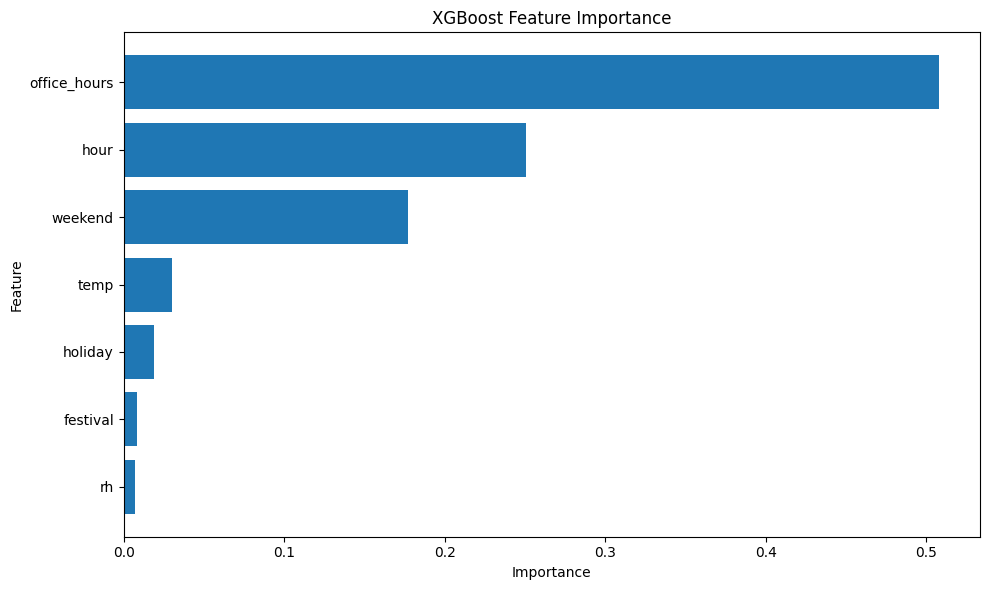

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance:")
display(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_xai)

print("SHAP analysis completed.")

SHAP analysis completed.


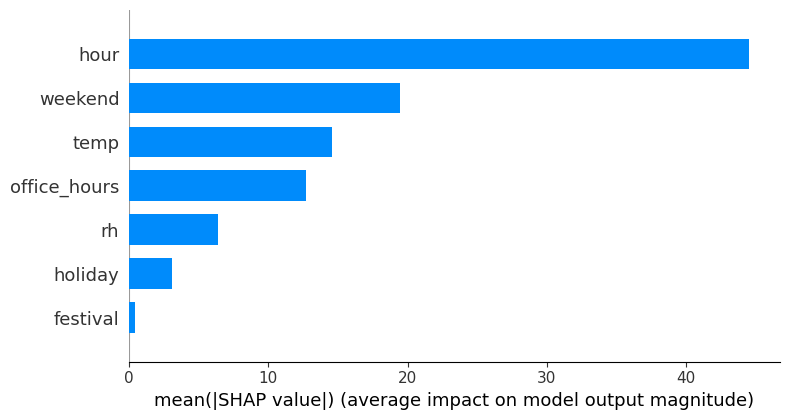

In [ ]:
# ============================================================
# GLOBAL SHAP IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values,
    X_xai,
    plot_type="bar"
)

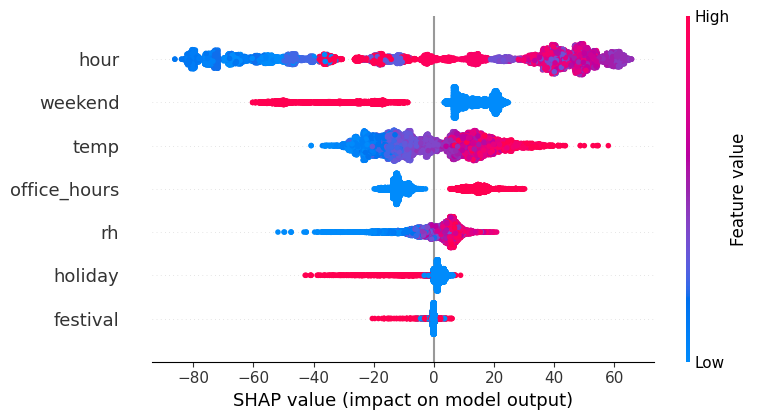

In [ ]:
# ============================================================
# SHAP BEESWARM
# ============================================================

shap.summary_plot(
    shap_values,
    X_xai
)

Selected Day: 2024-01-30


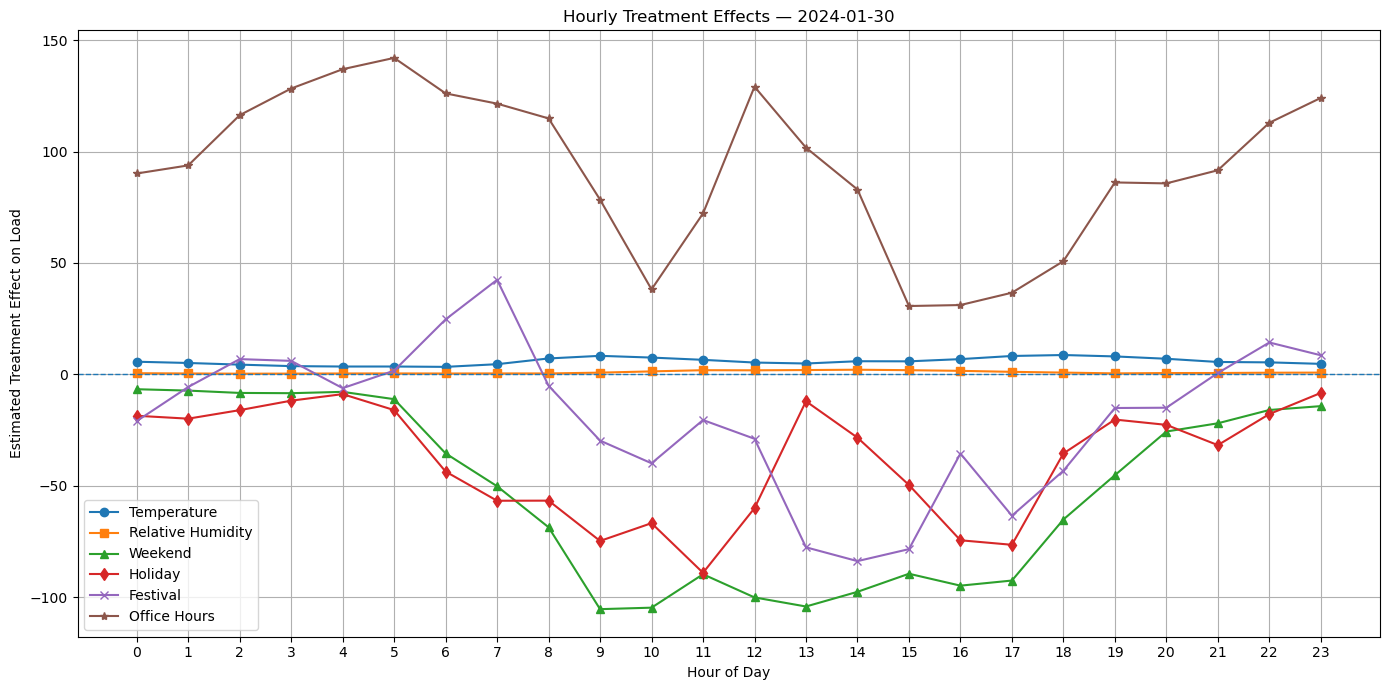

In [9]:
# =====================================================
# TREATMENT EFFECTS FOR A SINGLE DAY
# =====================================================

# Convert datetime to date
df["date"] = pd.to_datetime(df["datetime"]).dt.date

# -----------------------------------------------------
# Select any one day randomly
# -----------------------------------------------------

selected_date = np.random.choice(df["date"].unique())

print("Selected Day:", selected_date)


# -----------------------------------------------------
# Create treatment-effect dataframe
# -----------------------------------------------------

plot_df = pd.DataFrame({

    "date": df["date"],
    "hour": df["hour"],

    "Temperature": temp_effect,
    "Relative Humidity": rh_effect,

    "Weekend": weekend_effect,
    "Holiday": holiday_effect,
    "Festival": festival_effect,
    "Office Hours": office_effect

})


# -----------------------------------------------------
# Filter ONLY the selected day
# -----------------------------------------------------

day_df = plot_df[
    plot_df["date"] == selected_date
].copy()


# -----------------------------------------------------
# Average only the 15-minute observations
# within each hour of THIS ONE DAY
# -----------------------------------------------------

hour_effect_day = (
    day_df
    .groupby("hour")
    [
        [
            "Temperature",
            "Relative Humidity",
            "Weekend",
            "Holiday",
            "Festival",
            "Office Hours"
        ]
    ]
    .mean()
    .reset_index()
)


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(14, 7))


plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Temperature"],
    marker="o",
    label="Temperature"
)

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Relative Humidity"],
    marker="s",
    label="Relative Humidity"
)

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Weekend"],
    marker="^",
    label="Weekend"
)

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Holiday"],
    marker="d",
    label="Holiday"
)

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Festival"],
    marker="x",
    label="Festival"
)

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Office Hours"],
    marker="*",
    label="Office Hours"
)


# Zero reference
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


plt.xlabel("Hour of Day")

plt.ylabel(
    "Estimated Treatment Effect on Load"
)

plt.title(
    f"Hourly Treatment Effects — {selected_date}"
)

plt.xticks(range(24))

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()